### Importing Libraries

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

### Data Preprocessing

### Training Image Processing

In [37]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [38]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)


Found 17572 files belonging to 38 classes.


In [39]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[171.25 167.25 164.25]
   [170.5  166.5  163.5 ]
   [169.5  165.5  162.5 ]
   ...
   [133.25 128.25 124.25]
   [134.25 129.25 125.25]
   [137.5  132.5  128.5 ]]

  [[173.25 169.25 166.25]
   [172.   168.   165.  ]
   [170.   166.   163.  ]
   ...
   [131.   126.   122.  ]
   [133.75 128.75 124.75]
   [136.5  131.5  127.5 ]]

  [[169.5  165.5  162.5 ]
   [168.75 164.75 161.75]
   [167.25 163.25 160.25]
   ...
   [134.75 129.75 125.75]
   [134.   129.   125.  ]
   [132.25 127.25 123.25]]

  ...

  [[ 92.    89.    84.  ]
   [100.    97.    92.  ]
   [101.5   98.5   93.5 ]
   ...
   [ 75.    70.    64.  ]
   [ 75.75  70.75  64.75]
   [ 81.5   76.5   70.5 ]]

  [[ 97.75  94.75  89.75]
   [ 95.5   92.5   87.5 ]
   [ 92.75  89.75  84.75]
   ...
   [ 82.25  77.25  71.25]
   [ 79.5   74.5   68.5 ]
   [ 80.75  75.75  69.75]]

  [[ 93.    90.    85.  ]
   [ 96.    93.    88.  ]
   [ 97.25  94.25  89.25]
   ...
   [ 85.5   80.5   74.5 ]
   [ 86.    81.    75.  ]
   [ 85.    80.    7

### To Avoid Overshooting
1. Choose small learning rate default is 0.001, here we are taking 0.0001
2. There may be chance of Underfitting, so if we needed we'll increase number of neuron
3. Add more Convolution Layer to extract more feature from images, there may be possibility that model unable to capture relevent feature or model is confusing due to lack of feture so feed with more feture. 

### Building Model

In [40]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [41]:
model = Sequential()

### Building Convolution Layer

In [42]:
# Define the input shape
input_shape = (128, 128, 3)

# Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),  # Use Input(shape) as the first layer
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, strides=2)
])

In [43]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [44]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [45]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [46]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [47]:
model.add(tf.keras.layers.Dropout(0.25))  #to avoid overfitting

In [48]:
model.add(tf.keras.layers.Flatten())

In [49]:
model.add(tf.keras.layers.Dense(units=1500,activation='relu'))

In [50]:
model.add(tf.keras.layers.Dropout(0.5))  #to avoid overfitting

In [51]:
#Output Layer
model.add(tf.keras.layers.Dense(units=38,activation='softmax'))

### Compiling and Training Phase

### Compiling Model

In [52]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [53]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [54]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1545s 703ms/step - accuracy: 0.3543 - loss: 2.2993 - val_accuracy: 0.8399 - val_loss: 0.5029
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1532s 697ms/step - accuracy: 0.8208 - loss: 0.5806 - val_accuracy: 0.8682 - val_loss: 0.4239
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1535s 698ms/step - accuracy: 0.8972 - loss: 0.3227 - val_accuracy: 0.9097 - val_loss: 0.2788
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1533s 698ms/step - accuracy: 0.9280 - loss: 0.2218 - val_accuracy: 0.9330 - val_loss: 0.2093
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1529s 696ms/step - accuracy: 0.9480 - loss: 0.1634 - val_accuracy: 0.9478 - val_loss: 0.1681
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1528s 695ms/step - accuracy: 0.9590 - loss: 0.1227 - val_accuracy: 0.9510 - val_loss: 0.1602
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1533s 698ms/step - accuracy: 0.9684 - loss: 0.0955 - val_accuracy: 0.9541 - val_loss: 0.1502
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1531s 697ms/s

### Model Evaluation

In [56]:
#Training set Accuracy
train_loss, train_acc = model.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 383s 174ms/step - accuracy: 0.9863 - loss: 0.0477
Training accuracy: 0.9879223108291626


In [57]:
#Validation set Accuracy
val_loss, val_acc = model.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 ━━━━━━━━━━━━━━━━━━━━ 101s 183ms/step - accuracy: 0.9631 - loss: 0.1336
Validation accuracy: 0.9623833298683167


### Saving Model

In [58]:
model.save('trained_plant_disease_model.keras')

In [59]:
training_history.history #Return Dictionary of history

{'accuracy': [0.5598122477531433,
  0.8469877243041992,
  0.9079024195671082,
  0.9364250898361206,
  0.9520733952522278,
  0.9615193009376526,
  0.9693719148635864,
  0.975986897945404,
  0.9782203435897827,
  0.9812788963317871],
 'loss': [1.499183177947998,
  0.4889926016330719,
  0.2885814309120178,
  0.19550208747386932,
  0.14808551967144012,
  0.11499630659818649,
  0.09218961000442505,
  0.0743856206536293,
  0.06589225679636002,
  0.05773911625146866],
 'val_accuracy': [0.839858889579773,
  0.8681994080543518,
  0.9097427725791931,
  0.9330184459686279,
  0.9478147029876709,
  0.9510015845298767,
  0.9540746808052063,
  0.9654564261436462,
  0.9648303985595703,
  0.9623833298683167],
 'val_loss': [0.5028759241104126,
  0.42391344904899597,
  0.278845876455307,
  0.209273099899292,
  0.16807813942432404,
  0.16017569601535797,
  0.15018662810325623,
  0.11913970857858658,
  0.11861929297447205,
  0.13746054470539093]}

In [60]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [61]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


### Accuracy Visualization

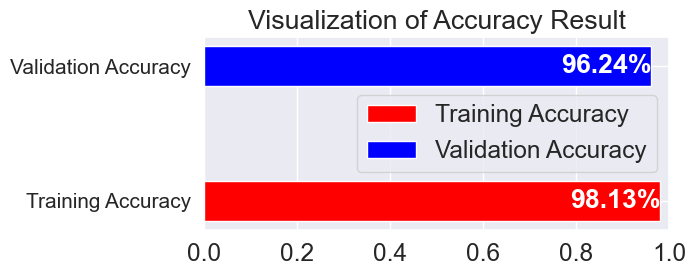

In [202]:
import matplotlib.pyplot as plt

training_accuracy = training_history.history['accuracy'][-1]
validation_accuracy = training_history.history['val_accuracy'][-1]

fig, ax = plt.subplots(figsize=(6, 2.5))  # Adjust the figure size

bar_width = 0.30  #  width of the bars

ax.barh([0], [training_accuracy], height=bar_width, color='red', label='Training Accuracy')
ax.barh([1], [validation_accuracy], height=bar_width, color='blue', label='Validation Accuracy')

ax.set_yticks([0, 1])
yticklabels = ax.set_yticklabels(['Training Accuracy', 'Validation Accuracy'])

# y-axis label font size
for label in yticklabels:
    label.set_fontsize(15)  # font size using set_fontsize

ax.set_xlim([0, 1])  # x-axis limits to match the accuracy scale

# Format accuracy as percentage
training_accuracy_str = f"{training_accuracy * 100:.2f}%"
validation_accuracy_str = f"{validation_accuracy * 100:.2f}%"

# Add accuracy values as labels
ax.text(training_accuracy, 0, training_accuracy_str, ha='right', va='center', color='white', fontweight='bold')
ax.text(validation_accuracy, 1, validation_accuracy_str, ha='right', va='center', color='white', fontweight='bold')

ax.set_title('Visualization of Accuracy Result')
ax.legend()
# Save the figure
plt.savefig('train_val_acc.png', dpi=300, bbox_inches='tight')
plt.show()

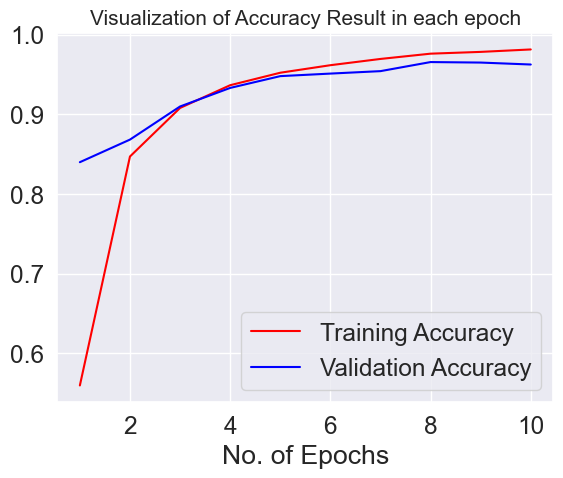

In [201]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result in each epoch', fontsize=15)
plt.legend()

plt.show()

### Some other matrics for model evaluation 

In [75]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [76]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [77]:
y_pred = model.predict(test_set)
y_pred, y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 93s 168ms/step


(array([[9.9959558e-01, 3.7955423e-04, 9.8762982e-08, ..., 1.4404870e-10,
         3.7885259e-09, 5.8596944e-10],
        [9.9676883e-01, 3.2304320e-03, 9.3345200e-11, ..., 9.4475556e-16,
         4.2310877e-12, 3.5373001e-14],
        [9.9997991e-01, 1.9898289e-05, 7.3054623e-10, ..., 8.9333812e-16,
         6.1161028e-12, 6.7695910e-14],
        ...,
        [3.1380393e-10, 1.0593099e-12, 4.9259812e-11, ..., 5.4375541e-12,
         7.3533166e-13, 9.9999893e-01],
        [2.5682886e-10, 7.3614769e-13, 1.2684376e-10, ..., 6.3280950e-11,
         3.7361425e-12, 9.9999988e-01],
        [1.2833564e-14, 2.8768018e-16, 3.4180954e-14, ..., 6.6624149e-14,
         8.7669265e-13, 9.9999714e-01]], dtype=float32),
 (17572, 38))

In [78]:
predicted_categories= tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [79]:
true_categories = tf.concat([y for x,y in test_set], axis=0)
true_categories

2024-04-16 14:15:34.756594: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [80]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [81]:
!pip install scikit-learn
from sklearn.metrics import classification_report,confusion_matrix 

In [82]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.89      0.93       504
                                 Apple___Black_rot       0.92      0.99      0.95       497
                          Apple___Cedar_apple_rust       0.98      0.98      0.98       440
                                   Apple___healthy       0.99      0.93      0.96       502
                               Blueberry___healthy       0.98      0.97      0.97       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.95      0.97       421
                 Cherry_(including_sour)___healthy       0.87      1.00      0.93       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.93      0.95       410
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.97      0.

In [83]:
cm = confusion_matrix(Y_true,predicted_categories)
cm 

array([[448,  32,   0, ...,   0,   1,   0],
       [  0, 490,   0, ...,   0,   0,   0],
       [  0,   1, 432, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 486,   0,   0],
       [  0,   0,   0, ...,   0, 446,   0],
       [  0,   0,   1, ...,   0,   0, 471]])

### Confusion Matrix Visualization

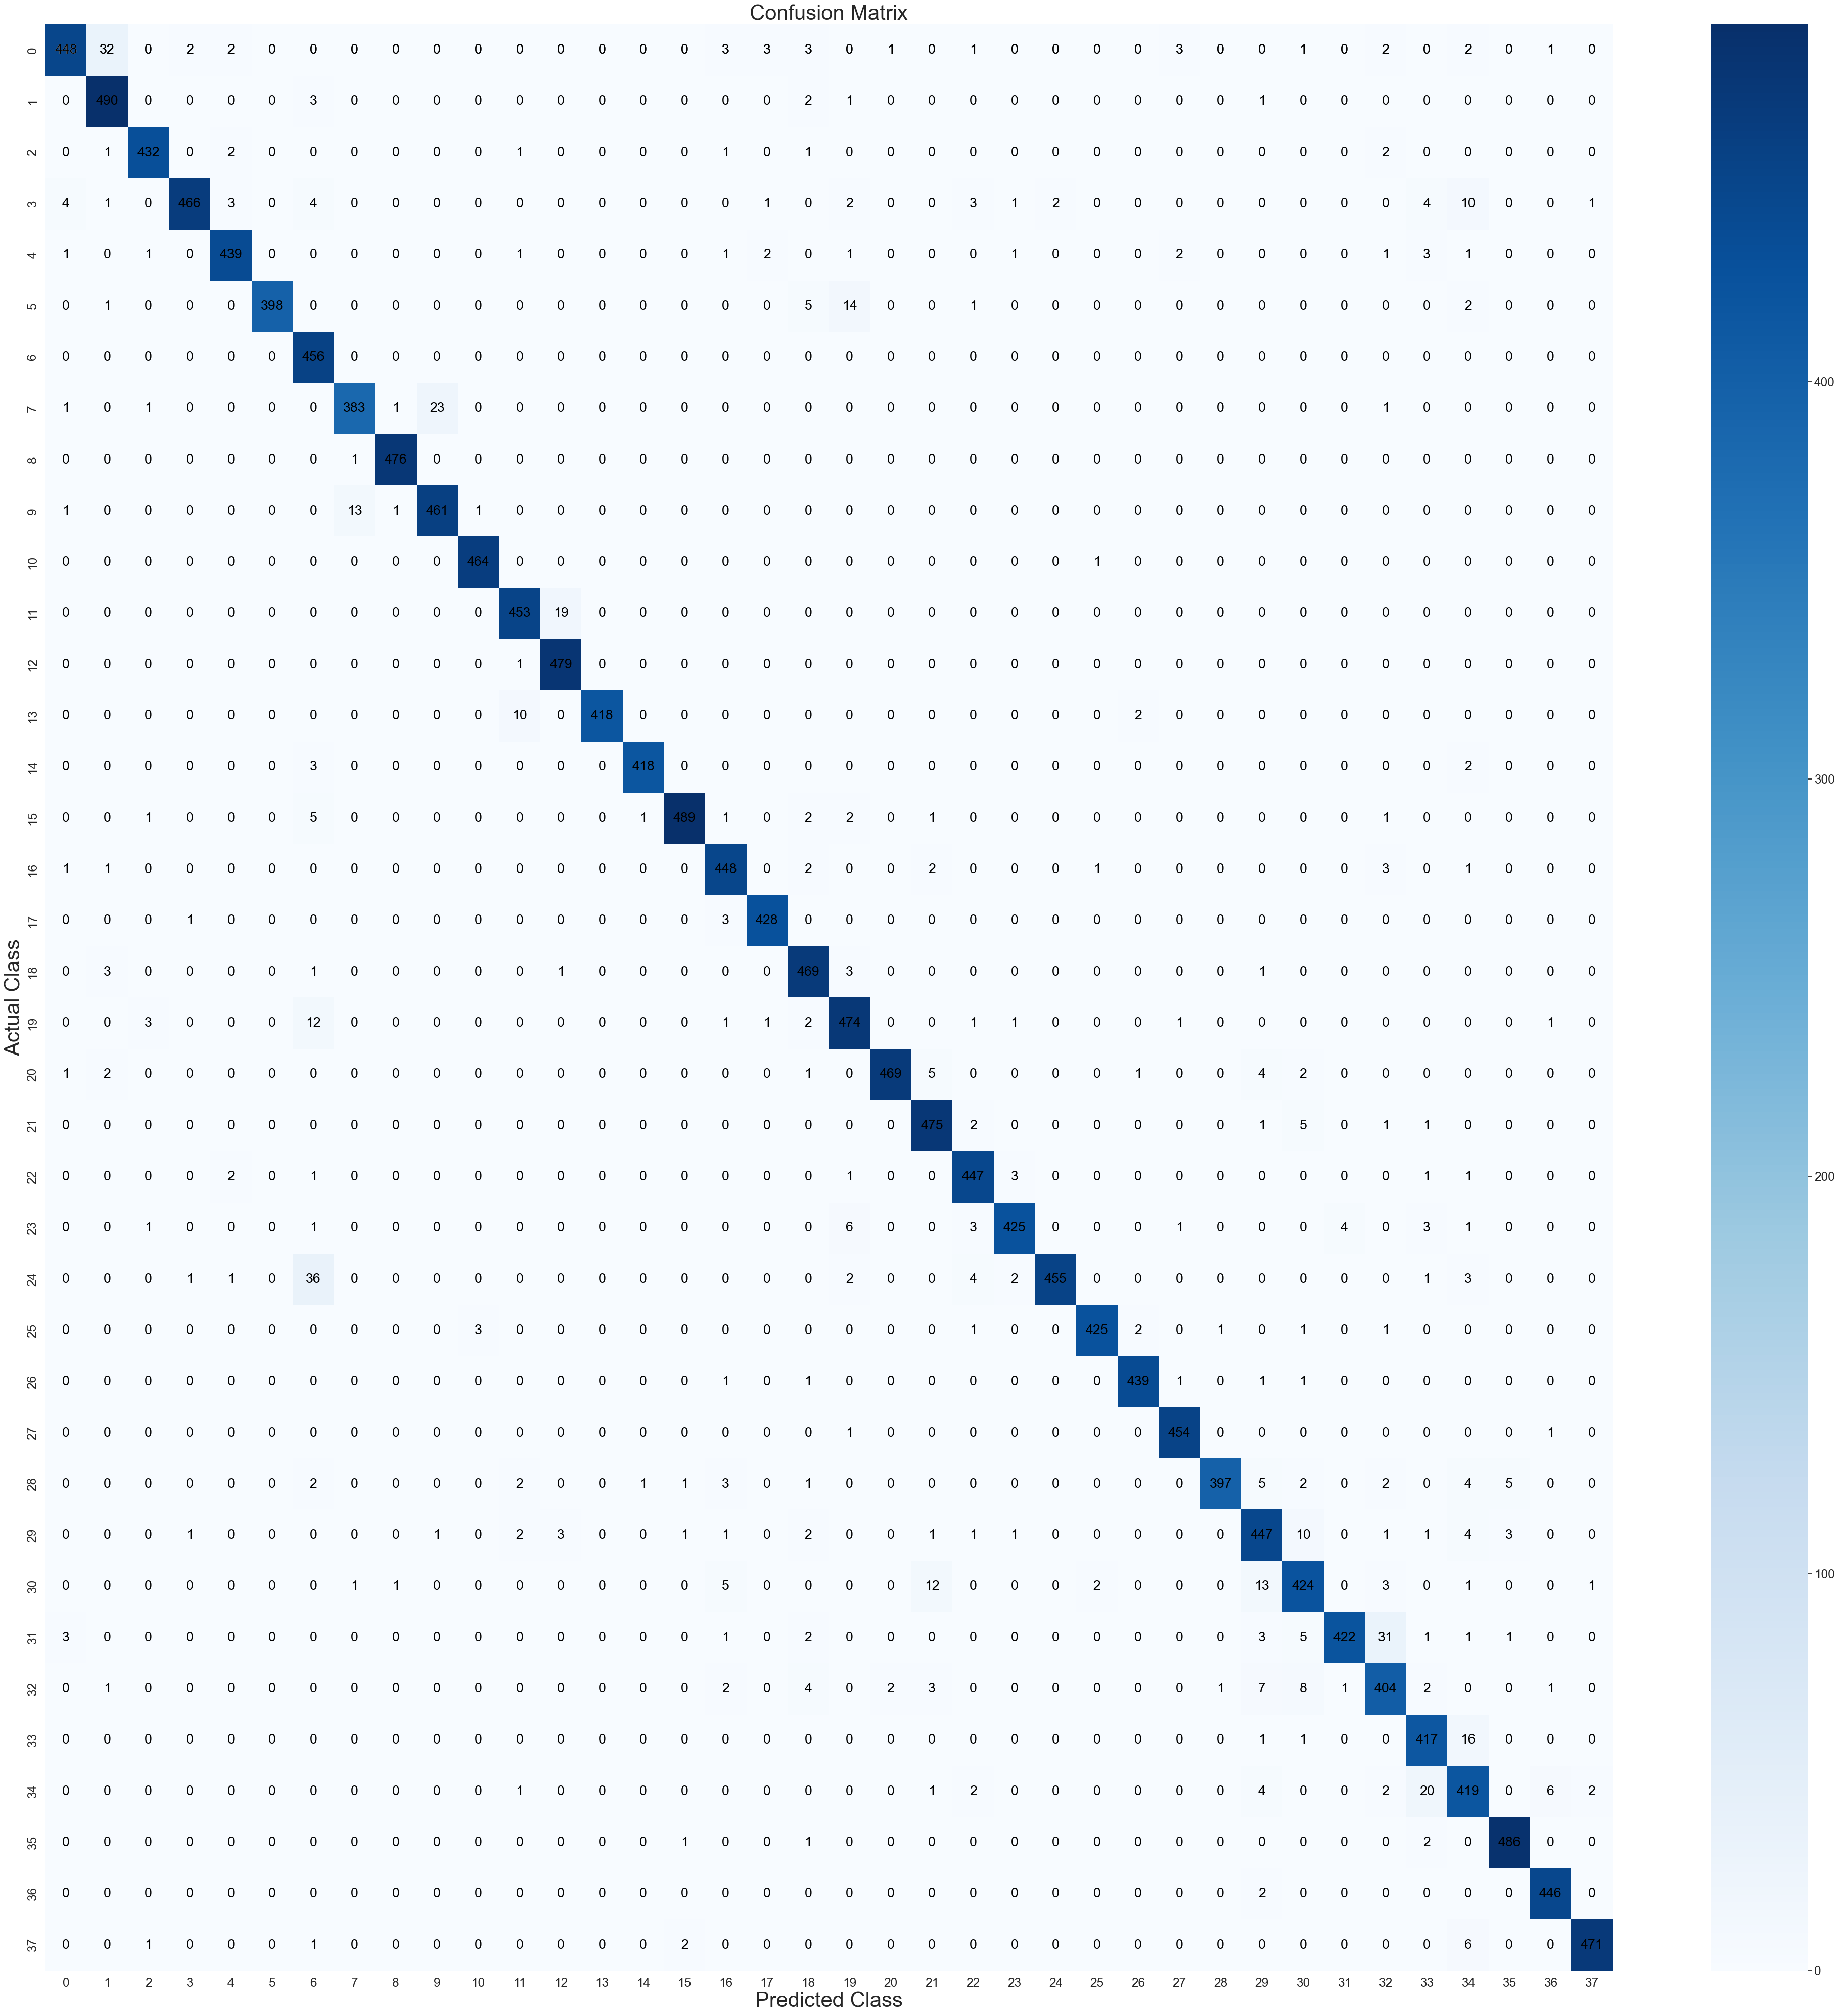

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the confusion matrix
plt.figure(figsize=(50, 50))
sns.set(font_scale=1.6)  # Adjust font scale
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Adding labels and title
plt.xlabel('Predicted Class', fontsize=30)
plt.ylabel('Actual Class', fontsize=30)
plt.title('Confusion Matrix', fontsize=30)

# Adding annotations
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j + 0.5, i + 0.5, cm[i, j], ha='center', va='center', color='Black')
plt.show()